**problem of statement**

**Implement  a linear regression that used to predict the price of house based on square footage,number of bathroom and number of bedrooom**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn as sk
from  sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import normalize

In [6]:
lr=LinearRegression()

load the data

In [44]:
data=pd.read_csv("/content/sample_data/train.csv")



In [45]:
print(data)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fe

select our target and criteria

In [48]:
train=data.drop(columns=data.columns.difference(['LotArea','SalePrice','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr']))
print(train)

      LotArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  \
0        8450             1             0         2         1             3   
1        9600             0             1         2         0             3   
2       11250             1             0         2         1             3   
3        9550             1             0         1         0             3   
4       14260             1             0         2         1             4   
...       ...           ...           ...       ...       ...           ...   
1455     7917             0             0         2         1             3   
1456    13175             1             0         2         0             3   
1457     9042             0             0         2         0             4   
1458     9717             1             0         1         0             2   
1459     9937             1             0         1         1             3   

      SalePrice  
0        208500  
1        181500

Discriptive statistics

In [13]:
stat=train.describe().transpose()

In [47]:
print(stat)

               count           mean           std      min       25%  \
LotArea       1460.0   10516.828082   9981.264932   1300.0    7553.5   
BsmtFullBath  1460.0       0.425342      0.518911      0.0       0.0   
BsmtHalfBath  1460.0       0.057534      0.238753      0.0       0.0   
FullBath      1460.0       1.565068      0.550916      0.0       1.0   
HalfBath      1460.0       0.382877      0.502885      0.0       0.0   
BedroomAbvGr  1460.0       2.866438      0.815778      0.0       2.0   
SalePrice     1460.0  180921.195890  79442.502883  34900.0  129975.0   

                   50%       75%       max  
LotArea         9478.5   11601.5  215245.0  
BsmtFullBath       0.0       1.0       3.0  
BsmtHalfBath       0.0       0.0       2.0  
FullBath           2.0       2.0       3.0  
HalfBath           0.0       1.0       2.0  
BedroomAbvGr       3.0       3.0       8.0  
SalePrice     163000.0  214000.0  755000.0  


normalization

In [15]:
normalized_data=normalize(train,norm='l2')

normalize data

In [49]:
print(normalized_data)

[[4.04943359e-02 4.79222910e-06 0.00000000e+00 ... 4.79222910e-06
  1.43766873e-05 9.99179768e-01]
 [5.28187301e-02 0.00000000e+00 5.50195105e-06 ... 0.00000000e+00
  1.65058532e-05 9.98604116e-01]
 [5.02719245e-02 4.46861551e-06 0.00000000e+00 ... 4.46861551e-06
  1.34058465e-05 9.98735567e-01]
 ...
 [3.39091936e-02 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  1.50007492e-05 9.99424918e-01]
 [6.82101591e-02 7.01967265e-06 0.00000000e+00 ... 0.00000000e+00
  1.40393453e-05 9.97670975e-01]
 [6.72171267e-02 6.76432794e-06 0.00000000e+00 ... 6.76432794e-06
  2.02929838e-05 9.97738371e-01]]


convert normalized data to pandas dataframe

In [42]:
normalized_df=pd.DataFrame(normalized_data,columns=train.columns)

label our target and criteria

In [43]:
df_x=normalized_df.drop(columns='SalePrice')
print(df_x)

       LotArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr
0     0.040494      0.000005      0.000000  0.000010  0.000005      0.000014
1     0.052819      0.000000      0.000006  0.000011  0.000000      0.000017
2     0.050272      0.000004      0.000000  0.000009  0.000004      0.000013
3     0.068056      0.000007      0.000000  0.000007  0.000000      0.000021
4     0.056947      0.000004      0.000000  0.000008  0.000004      0.000016
...        ...           ...           ...       ...       ...           ...
1455  0.045194      0.000000      0.000000  0.000011  0.000006      0.000017
1456  0.062615      0.000005      0.000000  0.000010  0.000000      0.000014
1457  0.033909      0.000000      0.000000  0.000008  0.000000      0.000015
1458  0.068210      0.000007      0.000000  0.000007  0.000000      0.000014
1459  0.067217      0.000007      0.000000  0.000007  0.000007      0.000020

[1460 rows x 6 columns]


In [41]:
df_y=normalized_df['SalePrice']
print(df_y)

0       0.999180
1       0.998604
2       0.998736
3       0.997681
4       0.998377
          ...   
1455    0.998978
1456    0.998038
1457    0.999425
1458    0.997671
1459    0.997738
Name: SalePrice, Length: 1460, dtype: float64


learn the machine

In [ ]:
lr.fit(df_x,df_y)

slope and y intercept

In [40]:
c=lr.intercept_
print('y_intrecept:',c)
m=lr.coef_
print('slope:',m)

y_intrecept: 1.0057878628309942
slope: [-1.83821650e-01  1.84692069e+01  4.51841172e+01 -7.39925930e+01
 -1.36201542e+02  2.08506182e+02]


prediction

In [39]:
y_predict_train=lr.predict(df_x)

visiualize the actual and prediction

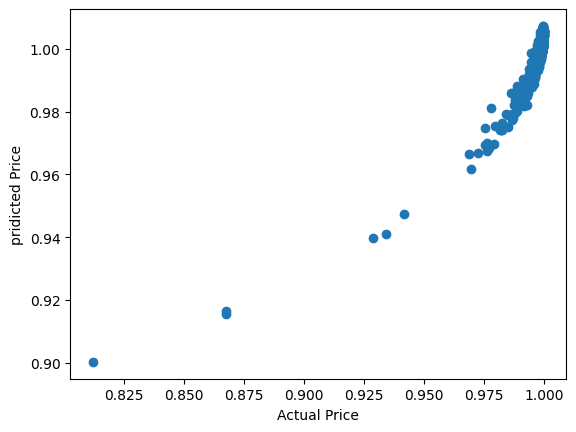

In [38]:
plt.scatter(df_y,y_predict_train)
plt.xlabel('Actual Price')
plt.ylabel('pridicted Price')
plt.show()

r square value

In [36]:
r2=r2_score(df_y,y_predict_train)
print('r square:',r2)

r square: 0.7520803435007257
